In [1]:
# jax ecosystem
import jax

jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_enable_x64", True)
print(jax.local_devices()[0].device_kind)

from jax import numpy as np, tree as jtu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import amigo
import dorito

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots  # to use matplotlib style "science"

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/code/amigo/src/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif gethostname() == "AJQ4YHQH9TX":
    path = "/Volumes/morgana1/snert/max/"
else:
    path = "/fred/oz440/max/"

source_name = "PDS70"
data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)


# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[17, 70] = 1
        file["BADPIX"].data[19, 53] = 1
        file["BADPIX"].data[5, 22] = 1
        file["BADPIX"].data[19, 41] = 1
        # file["BADPIX"].data[:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[76, 45] = 1
        file["BADPIX"].data[59, 30] = 1

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(sci_files, 30)

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}, PWCPOS {h["PWCPOS"]}'
    )
    t0 = t


------------------------------

HD 228337 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:07.785, Groups: 29, Ints: 418, PWCPOS 205.0233309999992
TD-PDS-70 F480M, Dither 1/1, Roll 301.7deg, 50.5min, 2023-02-24 21:05:08.000, Groups: 96, Ints: 418, PWCPOS 204.98422199999922


/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## Building the model

In [5]:
from amigo.model_fits import ModelFit
from amigo.vis_models import vis_to_im
from amigo.vis_analysis import AmigoOIData
from amigo.misc import interp
from jax import lax, numpy as np
import dLux as dl
import dLux.utils as dlu
import equinox as eqx


class MultiSourceFit(ModelFit):

    exposures: dict
    calibrator: bool = None  # this will mean multi fit
    unique_params: list = None

    def __init__(self, file, exp_dict, unique_params=None):

        super().__init__(file)

        for source_id, exp in exp_dict.items():
            if not isinstance(exp, ModelFit):
                raise ValueError(
                    f"All exposures must be ModelFit instances, got {type(exp)} for source_id {source_id}."
                )

        # Assert all exposures have the same filter
        filenames = [exp.filename for exp in exp_dict.values()]
        assert len(set(filenames)) == 1

        self.exposures = exp_dict
        self.calibrator = None  # this will mean multi fit
        if unique_params is None:
            unique_params = [
                "positions",
                "fluxes",
                "spectra",
                "log_dist",
                "contrast",
            ]
        self.unique_params = unique_params

    def get_key(self, param, source_id=None):

        if source_id is None:
            print("Warning: source_id is None in get_key, taking the first exposure.")
            source_id = list(self.exposures.keys())[0]

        exp = self.exposures[source_id]

        if param in self.unique_params:
            return "_".join([exp.get_key(param), source_id])

        return exp.get_key(param)

    def map_param(self, param, source_id=None):

        if source_id is None:
            print("Warning: source_id is None in map_param, taking the first exposure.")
            source_id = list(self.exposures.keys())[0]

        # Map the appropriate parameter to the correct key
        if param in self.unique_params:
            return f"{param}.{self.get_key(param, source_id)}"

        # Else its global
        return self.exposures[source_id].map_param(param)

    def get_spectra(self, model, source_id):
        wavels, filt_weights = model.filters[self.filter]
        xs = np.linspace(-1, 1, len(wavels), endpoint=True)
        spectra_slopes = 1 + model.get(self.map_param("spectra", source_id)) * xs
        weights = filt_weights * spectra_slopes
        weights = np.where(weights < 0, 0.0, weights)
        return wavels, weights / weights.sum()

    def model_wfs(self, model, source_id):
        pos = dlu.arcsec2rad(model.positions[self.get_key("positions", source_id)])
        wavels, weights = self.get_spectra(model, source_id)

        optics = self.update_optics(model, source_id)
        wfs = eqx.filter_jit(optics.propagate)(wavels, pos, weights, return_wf=True)

        # Convert Cartesian to Angular wf
        if wfs.units == "Cartesian":
            wfs = wfs.multiply("pixel_scale", 1 / optics.focal_length)
            wfs = wfs.set(["plane", "units"], ["Focal", "Angular"])
        return wfs

    def model_psf(self, model, source_id):
        wfs = self.model_wfs(model, source_id)
        return dl.PSF(wfs.psf.sum(0), wfs.pixel_scale.mean(0))

    def model_illuminance(self, psf, model, source_id):
        flux = self.ngroups * 10 ** model.fluxes[self.get_key("fluxes", source_id)]
        psf = eqx.filter_jit(model.detector.apply)(psf)
        return psf.multiply("data", flux)

    def update_optics(self, model, source_id):
        optics = model.optics
        if "aberrations" in model.params.keys():
            coefficients = model.aberrations[self.get_key("aberrations", source_id)]

            # Nuke the piston gradient to prevent degeneracy
            fixed_piston = lax.stop_gradient(coefficients[0, 0])
            coefficients = coefficients.at[0, 0].set(fixed_piston)

            # Stop gradient for science targets
            if not self.calibrator:
                coefficients = lax.stop_gradient(coefficients)
            optics = optics.set("pupil_mask.abb_coeffs", coefficients)

        if hasattr(model, "reflectivity"):
            coefficients = model.reflectivity[self.get_key("reflectivity", source_id)]
            optics = optics.set("pupil_mask.amp_coeffs", coefficients)

        # Set the defocus
        optics = optics.set(
            "defocus", model.defocus[self.get_key("defocus", source_id)]
        )

        return optics

    def simulate(self, model, return_slopes: bool = True, **kwargs):

        # model/propagate the PSF of each source separately!
        illuminances = []
        for source_id, exp in self.exposures.items():
            psf = self.model_psf(model, source_id)
            if isinstance(exp, BaseResolvedFit):
                image = exp.model_interferogram(
                    psf, model, source_id=source_id, **kwargs
                )
            else:
                image = psf
            image = image.downsample(model.source_oversample)
            illuminance = self.model_illuminance(image, model, source_id)
            illuminances.append(illuminance.data)

        illuminance = dl.PSF(np.array(illuminances).sum(axis=0), image.pixel_scale)

        # Just grab any old exposure to get the detector methods
        exp = list(self.exposures.values())[0]
        ramp = exp.model_ramp(illuminance, model)
        ramp = exp.model_read(ramp, model)

        if return_slopes:
            return ramp.set("data", np.diff(ramp.data, axis=0))
        return ramp

    # def rotate(self, distribution, clip=True, interp_method="linear"):
    #     pass

    def print_summary(self):
        for source_id, exp in self.exposures.items():
            print(f"Source ID: {source_id}")
            exp.print_summary()
            print()

    def rotate(self, distribution, clip=True, interp_method="linear", source_id=None):
        if source_id is None:
            print("Warning: source_id is None in rotate, taking the first exposure.")
            source_id = list(self.exposures.keys())[0]

        exposure = self.exposures[source_id]

        return exposure.rotate(distribution, clip, interp_method)

    # def __getattr__(self, name):
    #     # called only if attribute not found normally
    #     print(f"Delegating {name} to inner B")
    #     return getattr(list(self.exposures.values())[0], name)

    def __call__(self, model, return_slopes=True):
        return self.simulate(model, return_slopes=return_slopes).data

In [6]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# just two science exposures and one calibrator for this demo
# sci_exps = [PointResolvedFit(file) for file in sci_files]
exp_dict = {
    "TD": dorito.model_fits.PointResolvedFit(sci_files[0]),
    #     # "STAR": amigo.model_fits.PointFit(sci_files[0]),
    #     # "TD": dorito.model_fits.TransformedResolvedFit(sci_files[0]),
    "FS": amigo.model_fits.PointFit(sci_files[0]),
}
sci_exps = [MultiSourceFit(sci_files[0], exp_dict)]
# cal_exps = [amigo.model_fits.PointFit(file) for file in cal_files]
# exps = sci_exps + cal_exps
# exps = cal_exps
exps = sci_exps

# building the model
source_size = 81  # pixels
basis, window = dorito.bases.inscribed_annulus_basis(source_size, iterations=1)
init_dist = np.ones((source_size, source_size)) / window.sum()
model = dorito.models.TransformedResolvedModel(
    exposures=exps,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    state=load_dict(cache + "calibration.npy"),
    basis=basis,
    window=window,
    param_initers={"contrast": 0.04, "distribution": init_dist},
)

model.params["aberrations"] = load_dict("files/PDS70_CALFIT.npy")["aberrations"]
model.params["positions"]["01242_005_02_03_1_FS"] = np.array([-2.15, -0.71])
model.params["fluxes"]["01242_005_02_03_1_FS"] = np.array([2.5])
# model.params["fluxes"]["01242_005_02_03_1_TD"] = (
#     np.log10(0.04) + model.params["fluxes"]["01242_005_02_03_1_STAR"]
# )

## Optimisation Stage 1: Gradient Descent

In [7]:
pos_keys = []
spc_keys = []
flx_keys = []
for exp in exps:
    if not exp.calibrator:
        spc_keys.append(exp.map_param("spectra", "TD"))
        spc_keys.append(exp.map_param("spectra", "FS"))
        pos_keys.append(exp.map_param("positions", "TD"))
        flx_keys.append(exp.map_param("fluxes", "TD"))


from jax_gaussian import gaussian_filter

sig = 0.25


def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist
            log_dist = np.log10(distribution / distribution.sum())

            # basis = args["basis"]
            # window = args["window"]
            # distribution = 10 ** basis.from_basis(log_dist) * window
            # distribution = gaussian_filter(distribution, sigma=sig)
            # distribution += 1e-16 * ((window + 1) % 2)
            # log_dist = np.log10(distribution / distribution.sum())
            # log_dist = basis.to_basis(log_dist)
            params["log_dist"][k] = log_dist

    if "spectra" in params.keys():
        spectra = jax.tree.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample

In [8]:
def logTV(model, exposure, source_id=None):
    return dorito.stats.TV_loss(
        model.get_distribution(exposure, source_id=source_id, exponentiate=False)
    )

In [9]:
def apply_regularisers(model, exposure, args, source_id=None):

    if "reg_dict" not in args.keys():
        return 0.0

    # evaluating the regularisation term with each for each regulariser
    priors = [
        coeff * fun(model, exposure, source_id=source_id)
        for coeff, fun in args["reg_dict"].values()
    ]

    # summing the different regularisers
    return np.array(priors).sum()


# def ramp_regularised_loss_fn(model, exp, args={"reg_dict": {}}):
#     # this is per exposure

#     # regular likelihood term
#     likelihood = -np.nanmean(exp.mv_zscore(model))

#     match exp.calibrator:
#         case True:
#             prior = 0.0
#         case False:
#             prior = apply_regularisers(model, exp, args)
#         case None:
#             if "source_id" in args.keys():
#                 source_id = args["source_id"]
#                 prior = apply_regularisers(
#                     model, exp.exposures[source_id], args, source_id=source_id
#                 )
#             else:
#                 prior = 0.0

#     return likelihood + prior, ()

In [11]:
apply_regularisers(model, exps[0], args)

NameError: name 'args' is not defined

In [ ]:
n_epoch = 300

config = {
    "positions": sgd(3e-3, 0),
    "fluxes": sgd(2e-2, 0),
    # "aberrations": sgd(2e-2, 4),
    "spectra": sgd(4e-2, 10),
    "log_dist": adam(2e-1, 10),
    # "log_dist": adam(5e-1, 30),
    "contrast": adam(2e-2, 15),
    # "log_dist": adam(5e-2, 0),
    # "fluxes": sgd(2e-2, 0),
}


def grad_fn(model, grads, args):

    # Reduce spectra gradients for the science exposures
    # if "spectra" in config.keys():
    #     grads = grads.multiply(spc_keys, 0.3)

    # if "fluxes" in config.keys():
    #     grads = grads.multiply(flx_keys, 0.01)
    return grads, args


args = {
    "reg_dict": {
        # "ME": (5e-2, dorito.stats.ME),
        # "TV": (1e-2, dorito.stats.TV),
        "TV": (1e14, logTV),
    },
    "source_id": "TD",
    # "basis": basis,
    # "window": window,
}

trainer = amigo.fitting.Trainer(
    loss_fn=dorito.stats.ramp_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    model,
    exps,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys() if p not in ["log_dist", "contrast"]],
)

print("Number of exposures: ", len(exps))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exps,
    args=args,
)

Populating fishers...
Number of exposures:  1


  0%|          | 0/300 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 607.44
Estimated run time: 0:04:11
Full Time: 0:04:33
Final Loss: 120.62


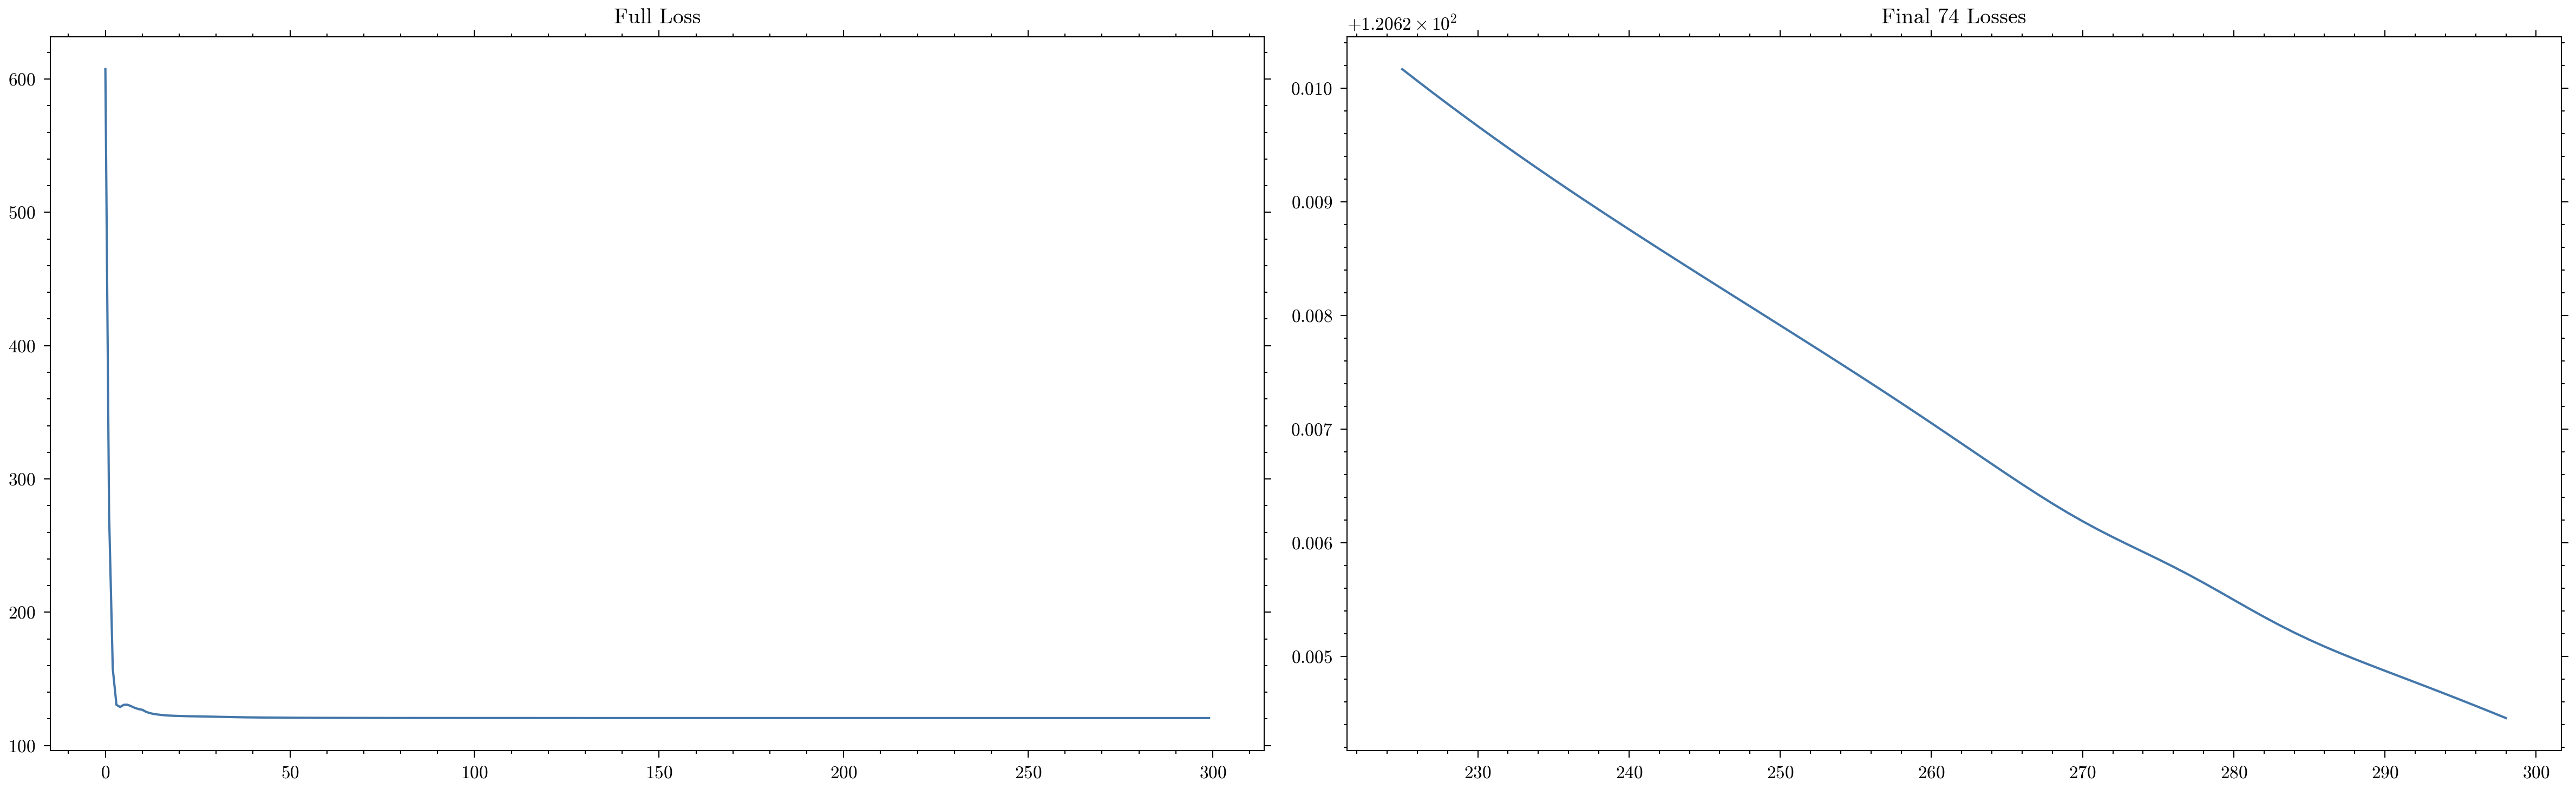

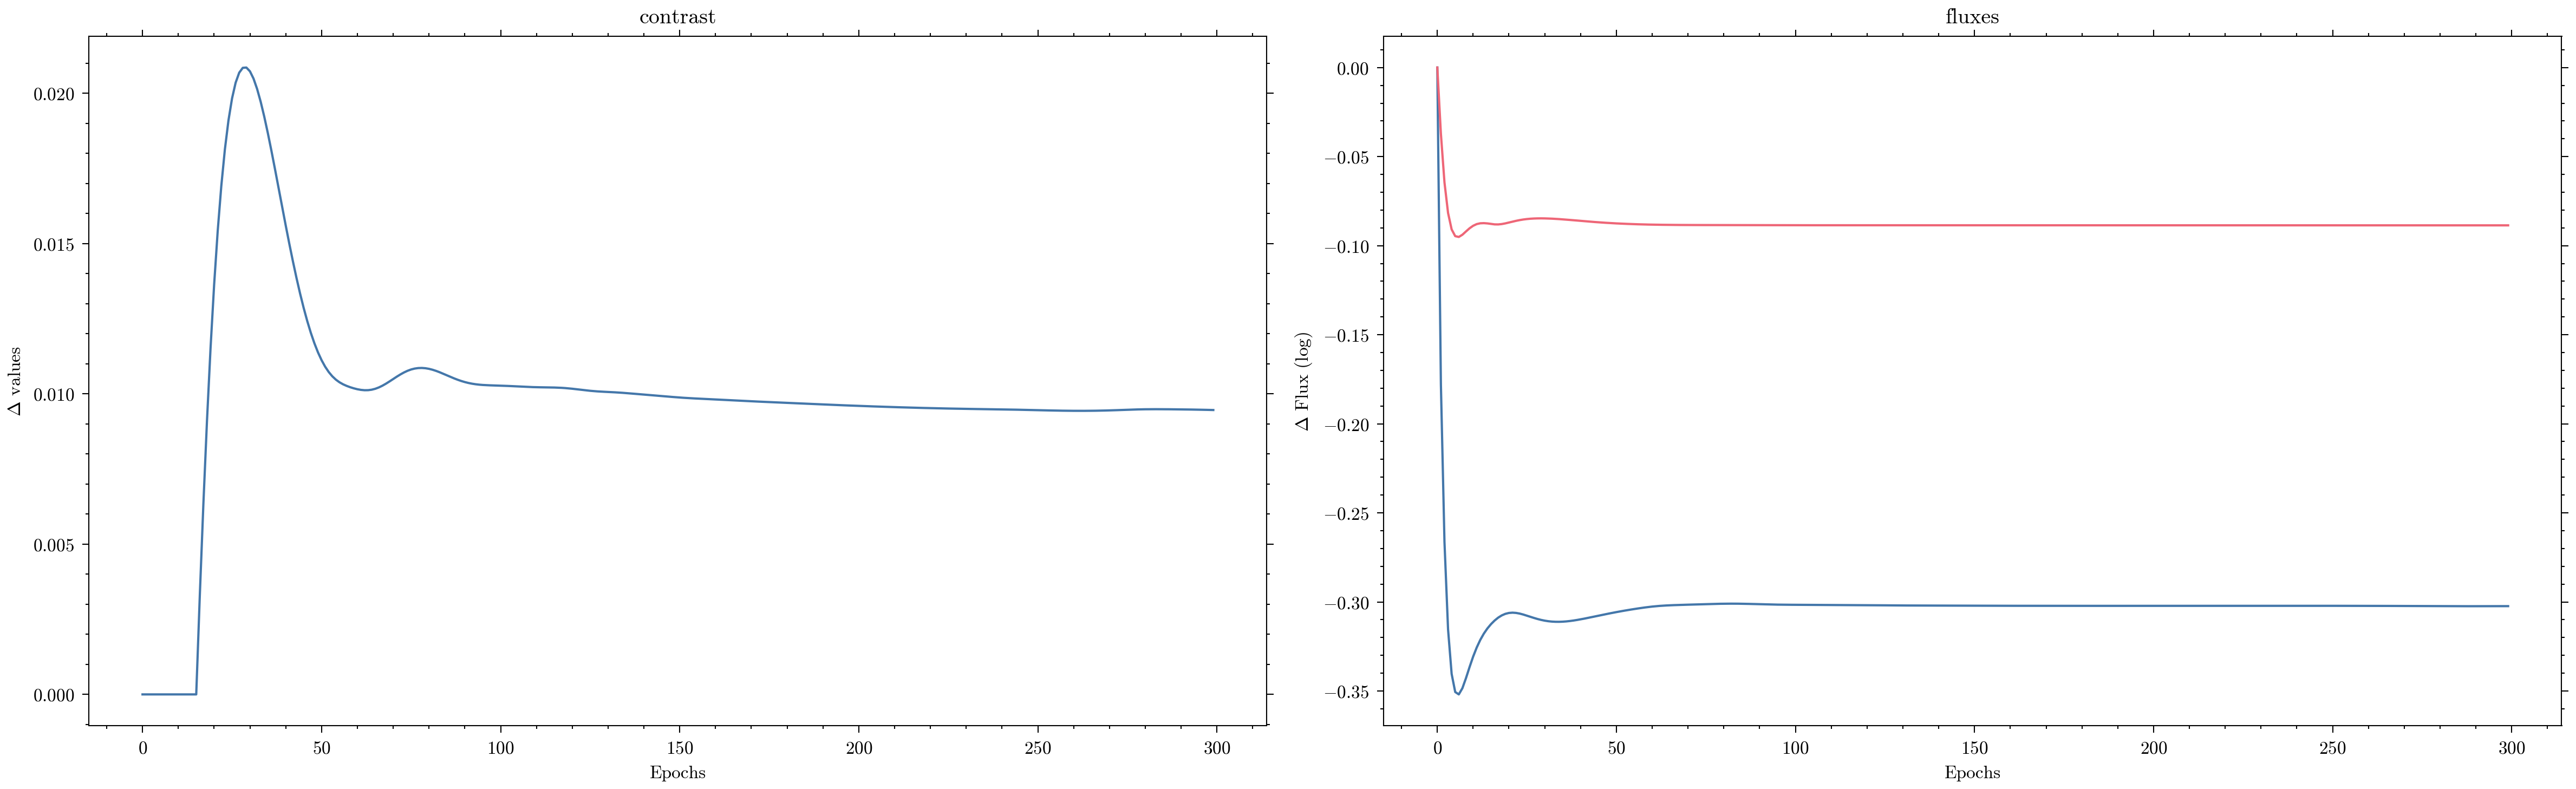

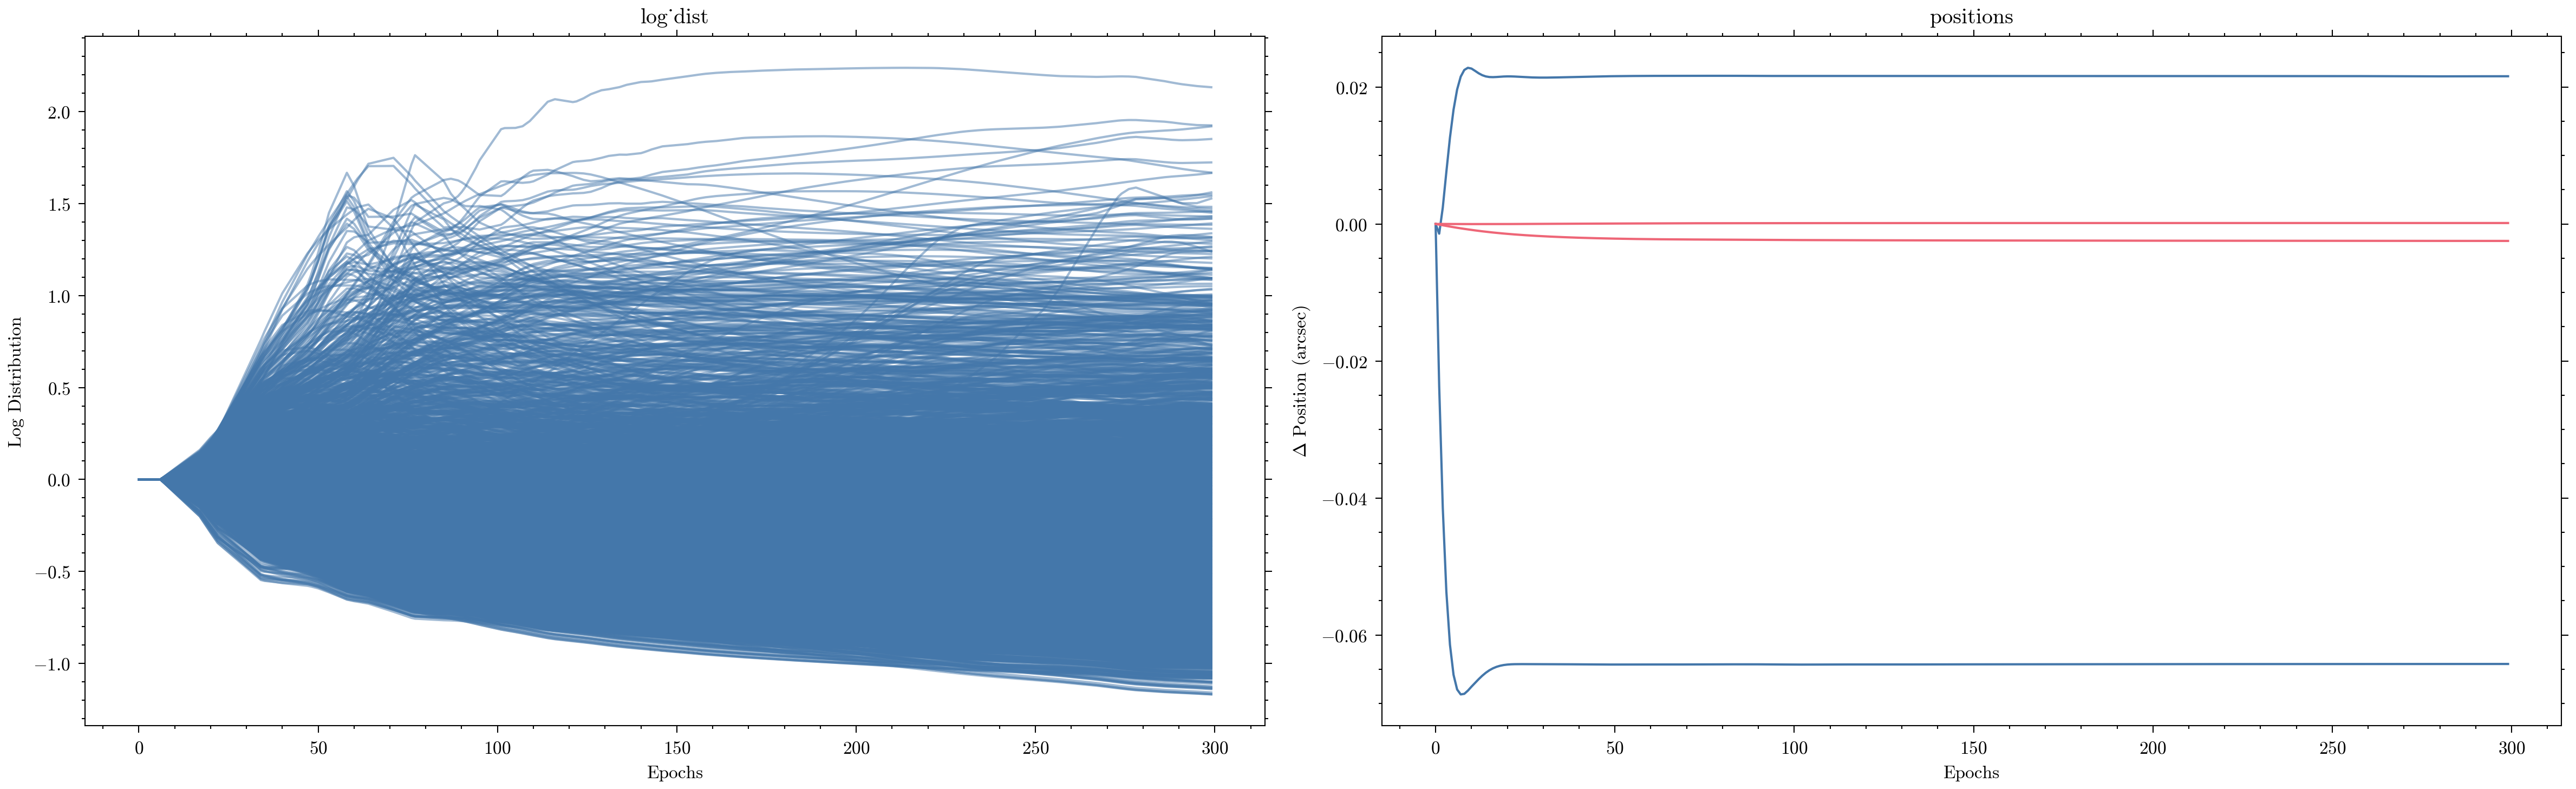

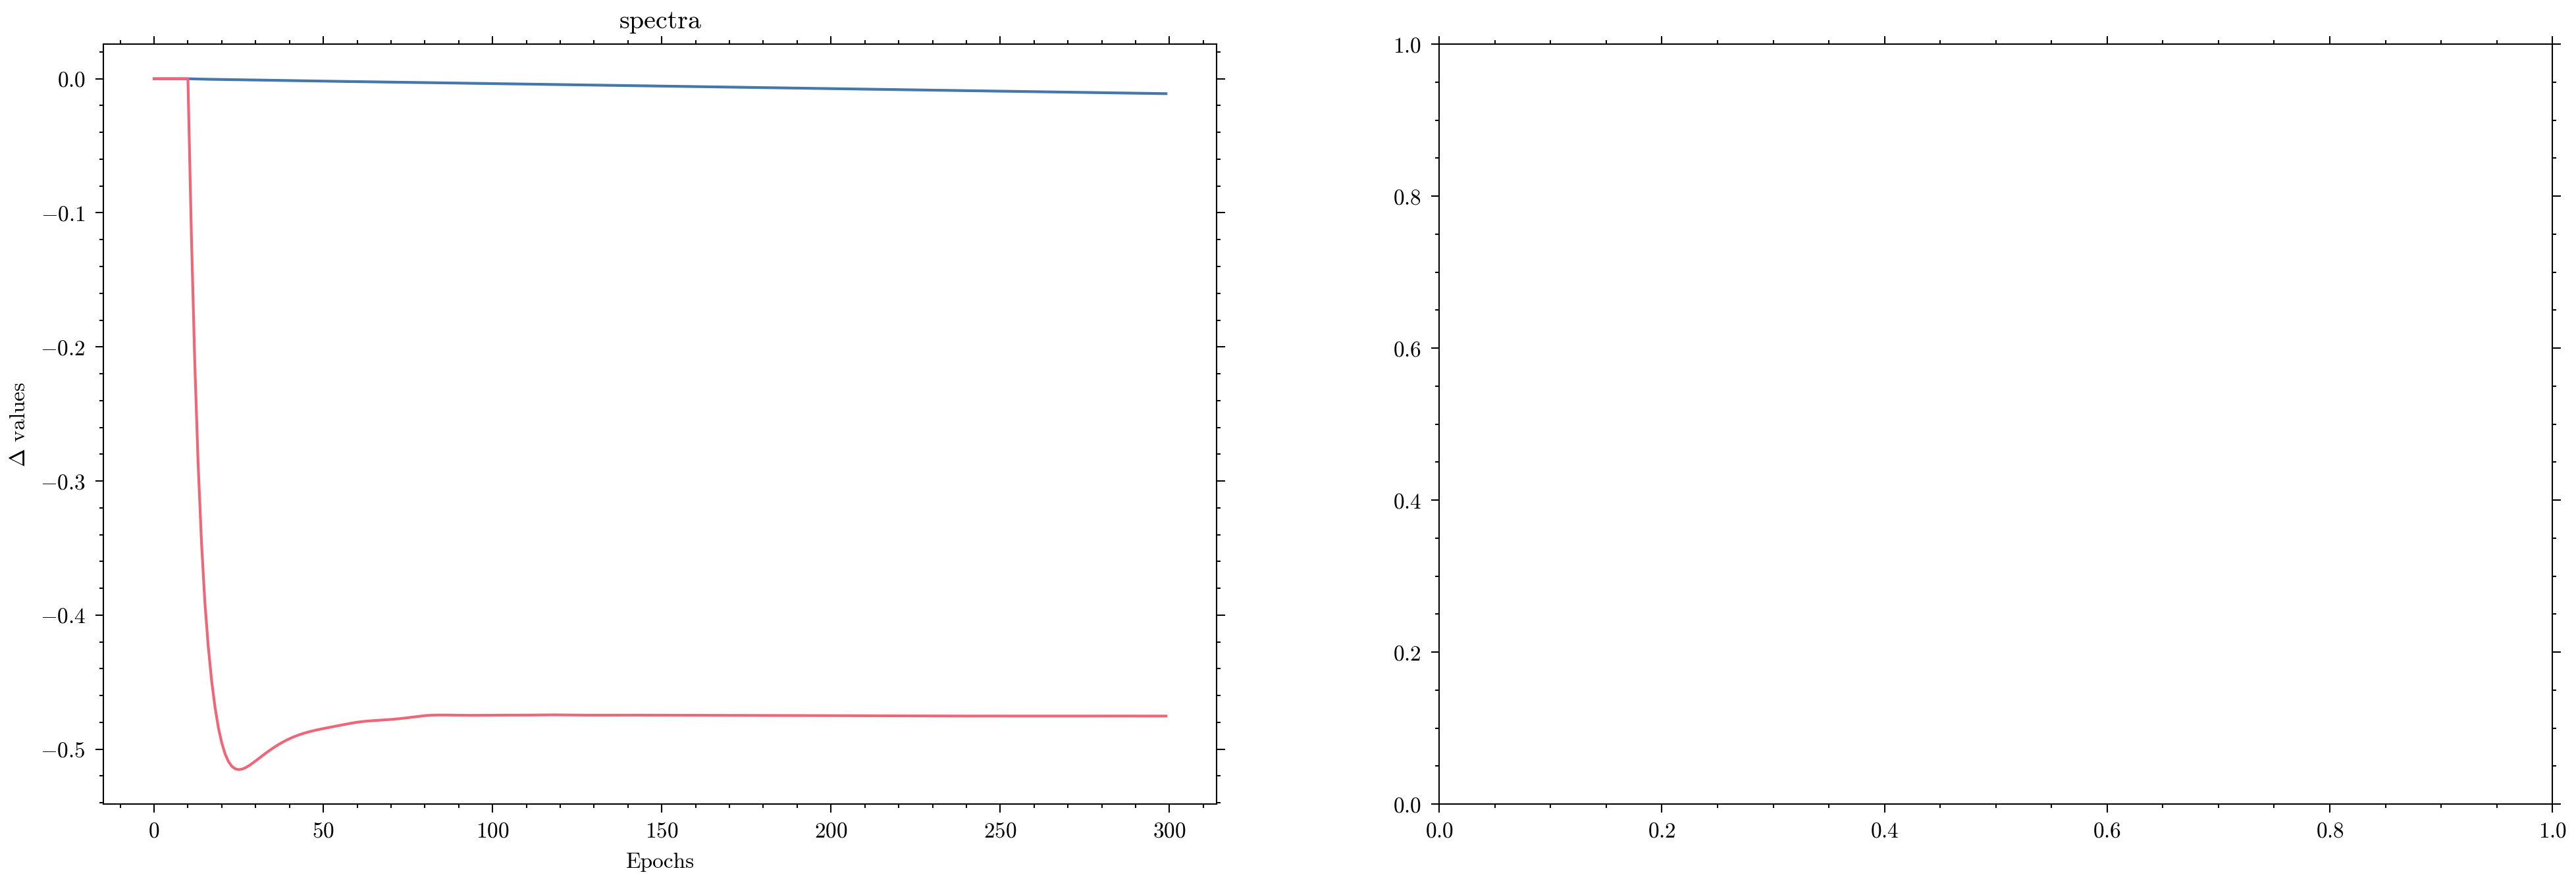

Source ID: TD
File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96


Source ID: FS
File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96




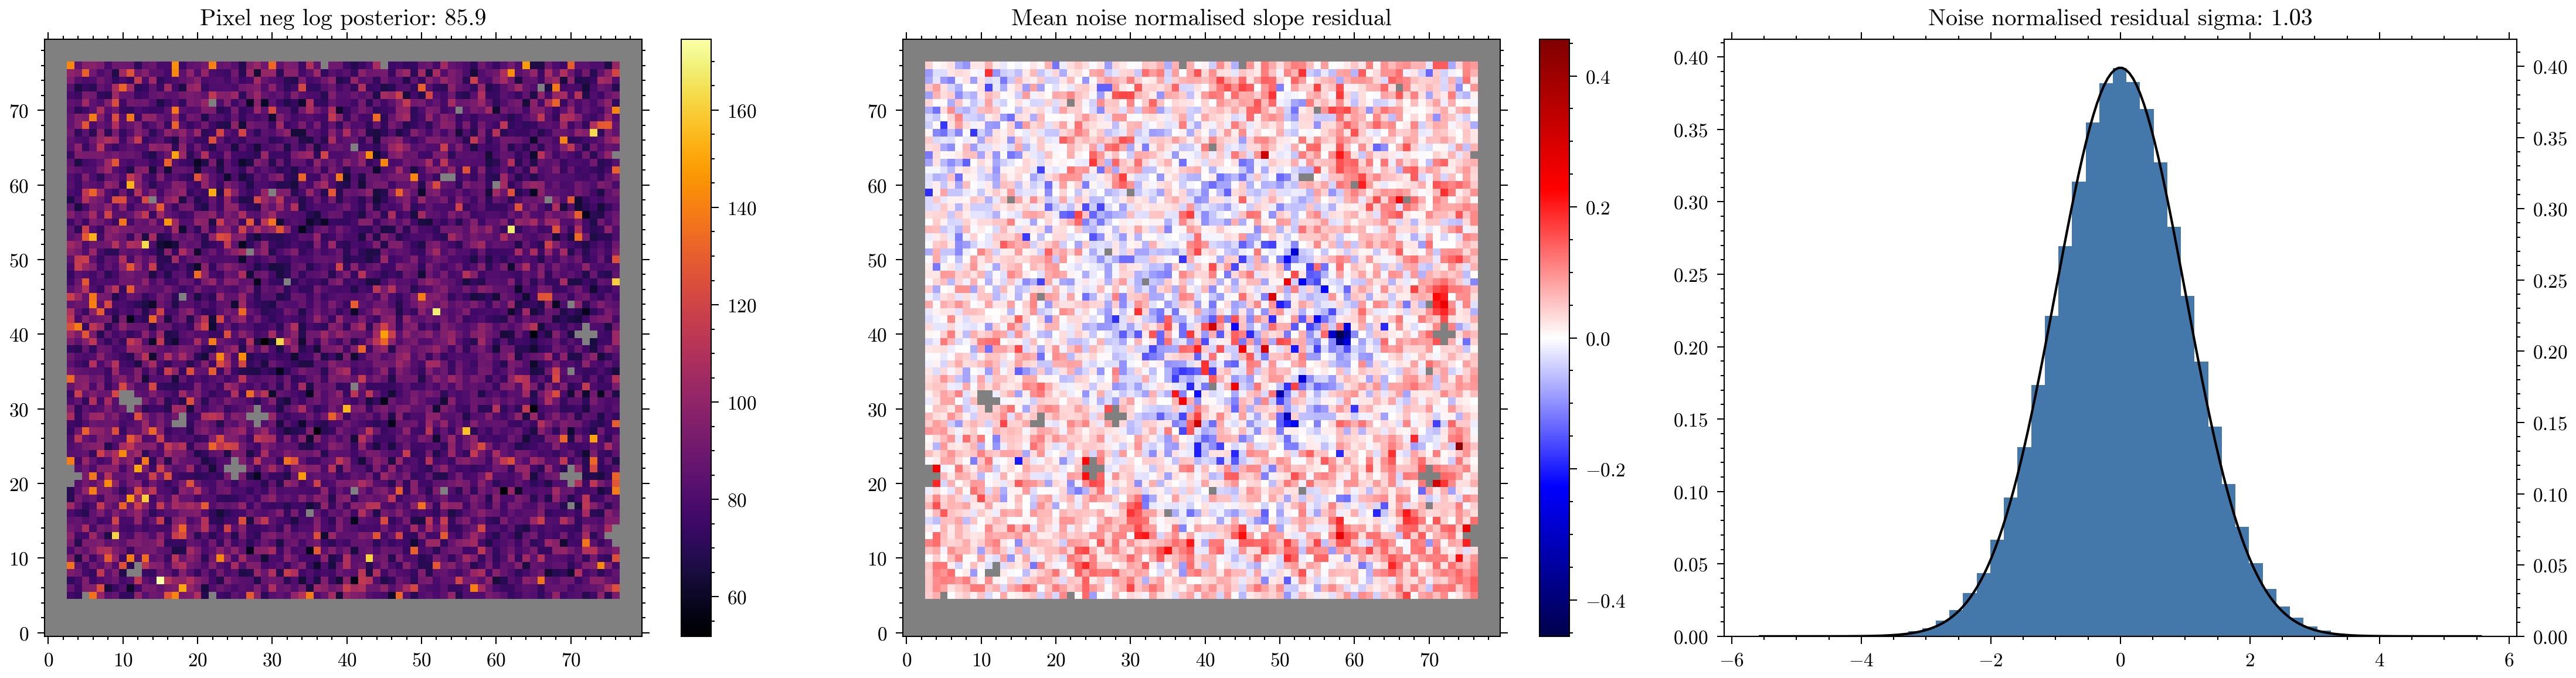

In [ ]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

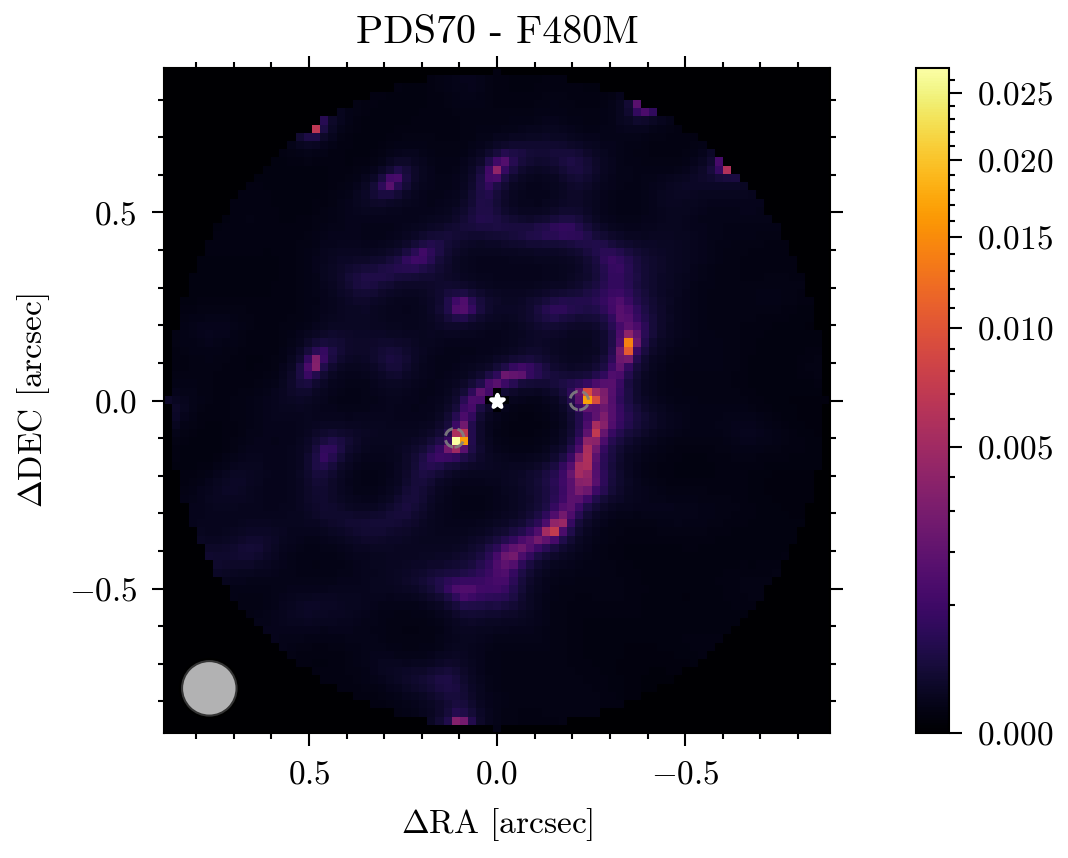

In [ ]:
from dLux import utils as dlu

# np.save("files/pds70_abs.npy", result.model.params["aberrations"], allow_pickle=True)


def eff_wavel(model, filt):
    wavels, weights = model.filters[filt]
    return np.dot(wavels, weights)


result_model = result.model
optics_diameter = 6.603464  # JWST aperture diameter in meters

for exp in exps:

    if exp.calibrator:
        continue
    dist = result_model.get_distribution(
        exp.exposures["TD"], rotate=False, source_id="TD"
    )
    fig, ax = plt.subplots(figsize=(6, 3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="inferno",
        # roll_angle_degrees=-exp.parang,
        norm=mpl.colors.PowerNorm(0.5, vmin=None),
        # norm=mpl.colors.PowerNorm(0.3, vmax=0.3),
        diff_lim=0.5 * dlu.rad2arcsec(eff_wavel(model, exp.filter) / optics_diameter),
        # scale=1.5,
    )

    fig.colorbar(c0)

    ax.set(title=f"PDS70 - {exp.filter}")  #   xticks=ticks, yticks=ticks)
    ax.scatter([0], [0], marker="*", color="white", s=10)

    seps = 1e-3 * np.array([150.5, 218.4])
    pas = np.array([131.2, 270.0])
    xs = seps * np.cos(np.radians(pas))
    ys = seps * np.sin(np.radians(pas))
    ax.scatter(
        ys,
        xs,
        marker="o",
        alpha=0.9,
        s=20,
        facecolors="none",
        edgecolors="grey",
        linestyle="--",
        linewidths=0.7,
    )

    plt.tight_layout()
    plt.show()
    # plt.savefig(output_path + f"{exp.key}_dist.png", dpi=300)

In [ ]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


params = [
    # "amplitudes",
    # "phases",
    "fluxes",
    "spectra",
]
final_model = result.model

args_out = {}
sols_out = {}
for exp in exps:
    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    try:
        print("Initial loss:", fun(initial_params, args))
    except Exception as e:
        print(f"Skipped {exp.key}")
        continue
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(fun, solver, initial_params, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Initial loss: 50.06011267514419
Final loss: 50.060112647996
9 5




In [ ]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)
final_model = result.model


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)

    model_params, _ = norm_fn(model_params, {})

    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


params = [
    "positions",
    "log_dist",
    "contrast",
    # "aberrations",
    "fluxes",
    "spectra",
]
# final_model = result.model

args_out = {}
sols_out = {}
for exp in exps:

    # if exp.key in sols_out.keys():
    #     print(f"Skipping {exp.key} as it is already solved.")
    #     continue

    # if exp.calibrator:
    #     print(f"Skipping calibrator {exp.key}.")
    #     continue

    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        if param in trainer.fishers.keys():
            fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    try:
        print("Initial loss:", fun(initial_params, args))
    except Exception as e:
        print(f"Skipped {exp.key}")
        continue
    solver = optx.BFGS(rtol=1e-4, atol=1e-4)
    sol = optx.minimise(fun, solver, initial_params, args, throw=False, max_steps=2**14)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Skipped 01242_005_02_03_1


In [ ]:
spectra = {}
for key, args in args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

    # Spectra is joint-fit so we take the mean
    exp = args[1]
    spec = model_params.params[exp.map_param("spectra")]
    spec_key = exp.get_key("spectra")
    if spec_key not in spectra:
        spectra[spec_key] = [spec]
    else:
        spectra[spec_key].append(spec)

spectra = jtu.map(
    lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list)
)
final_model = final_model.set("spectra", spectra)

final_state = {}
for key, values in result.state.items():
    final_state[key] = final_model.get(key)

F380M Calibrator HD 228337 10


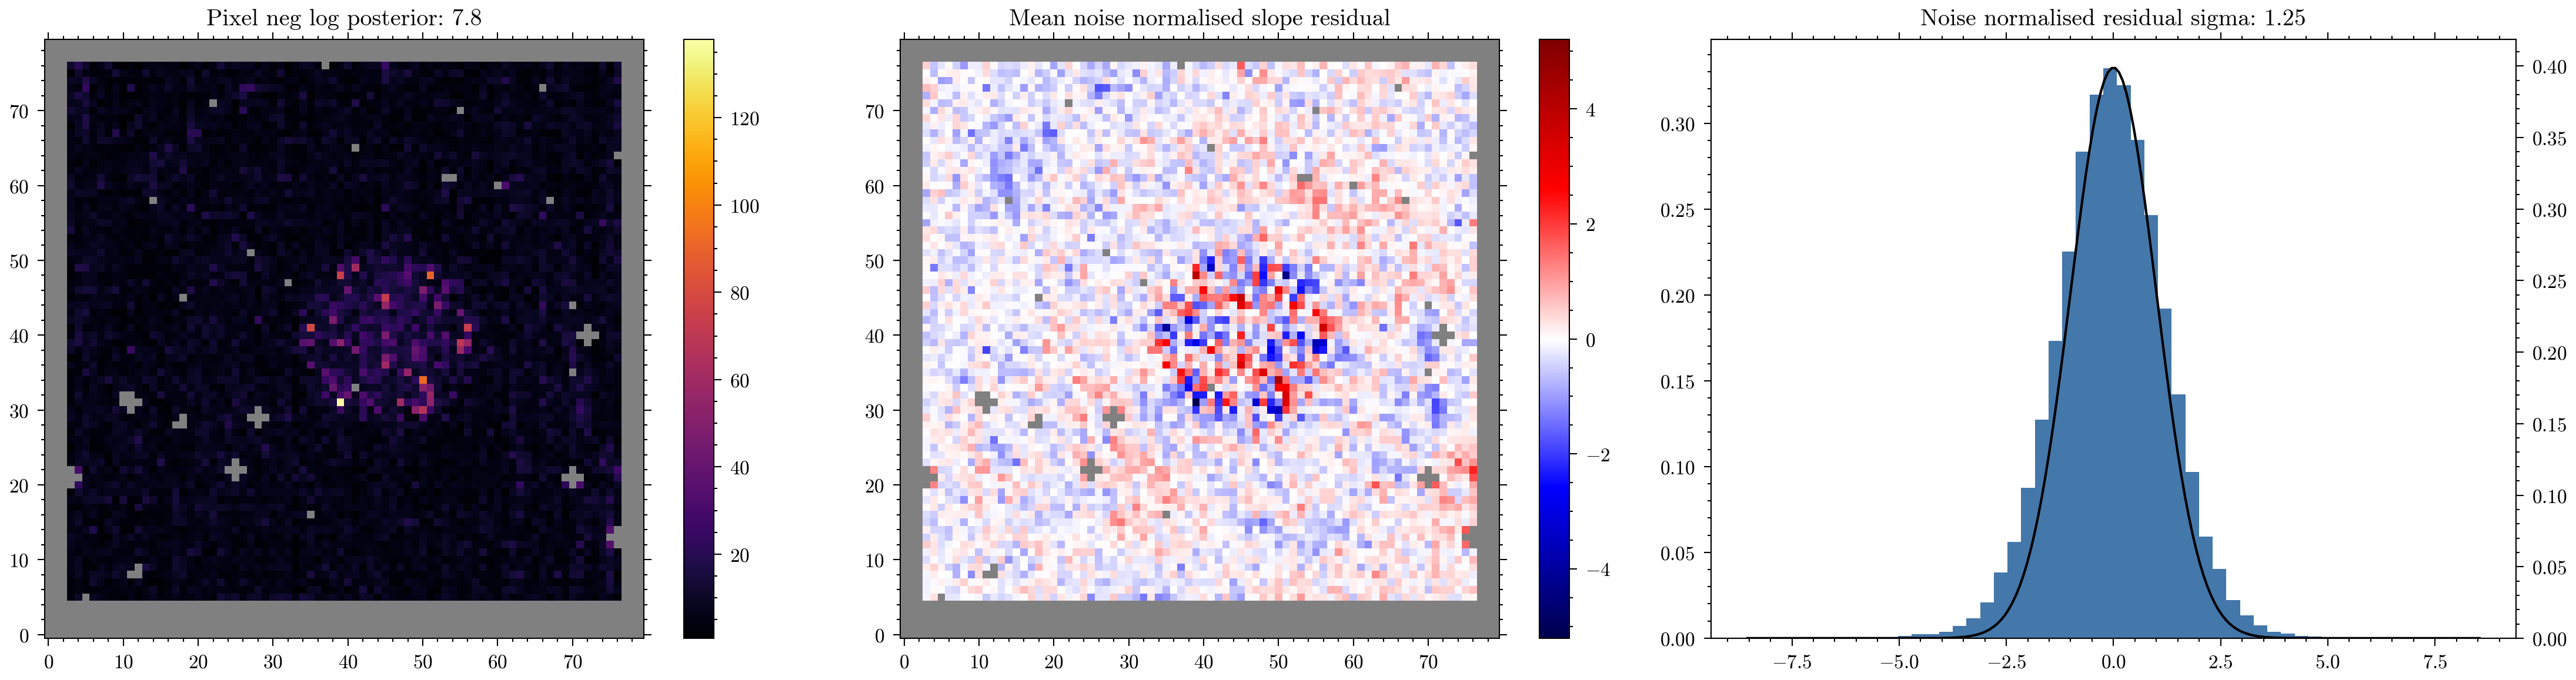

F430M Calibrator HD 228337 20


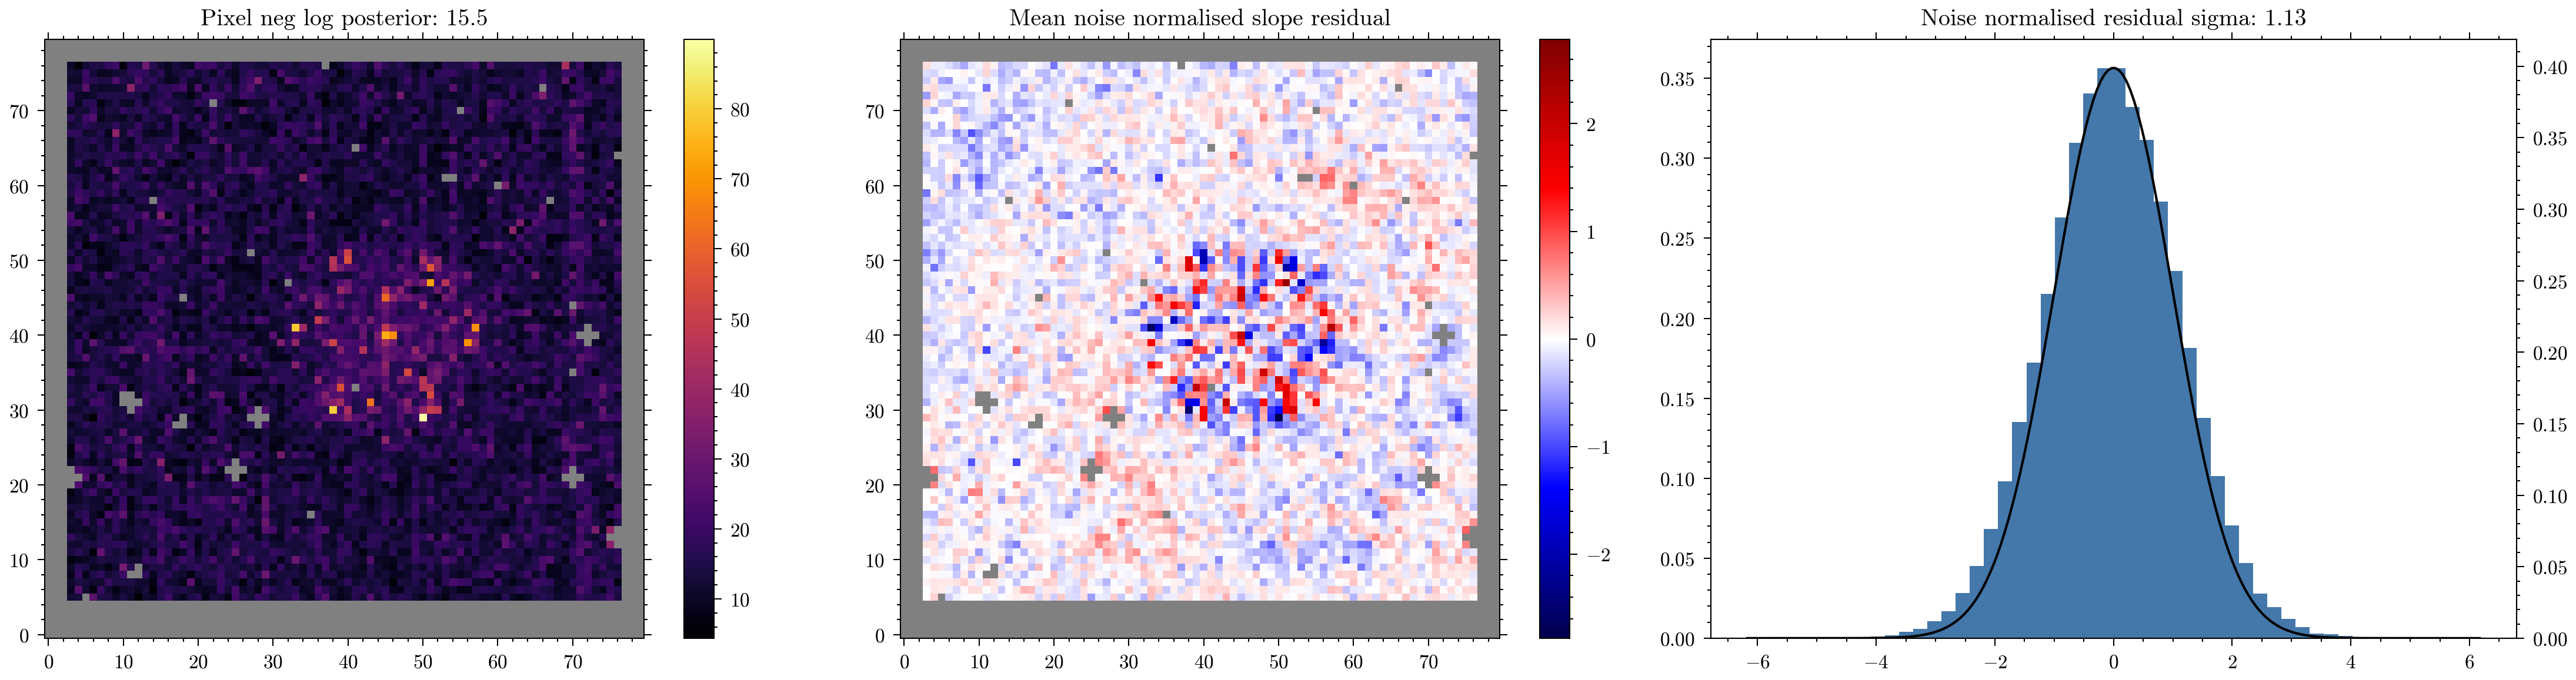

F480M Calibrator HD 228337 29


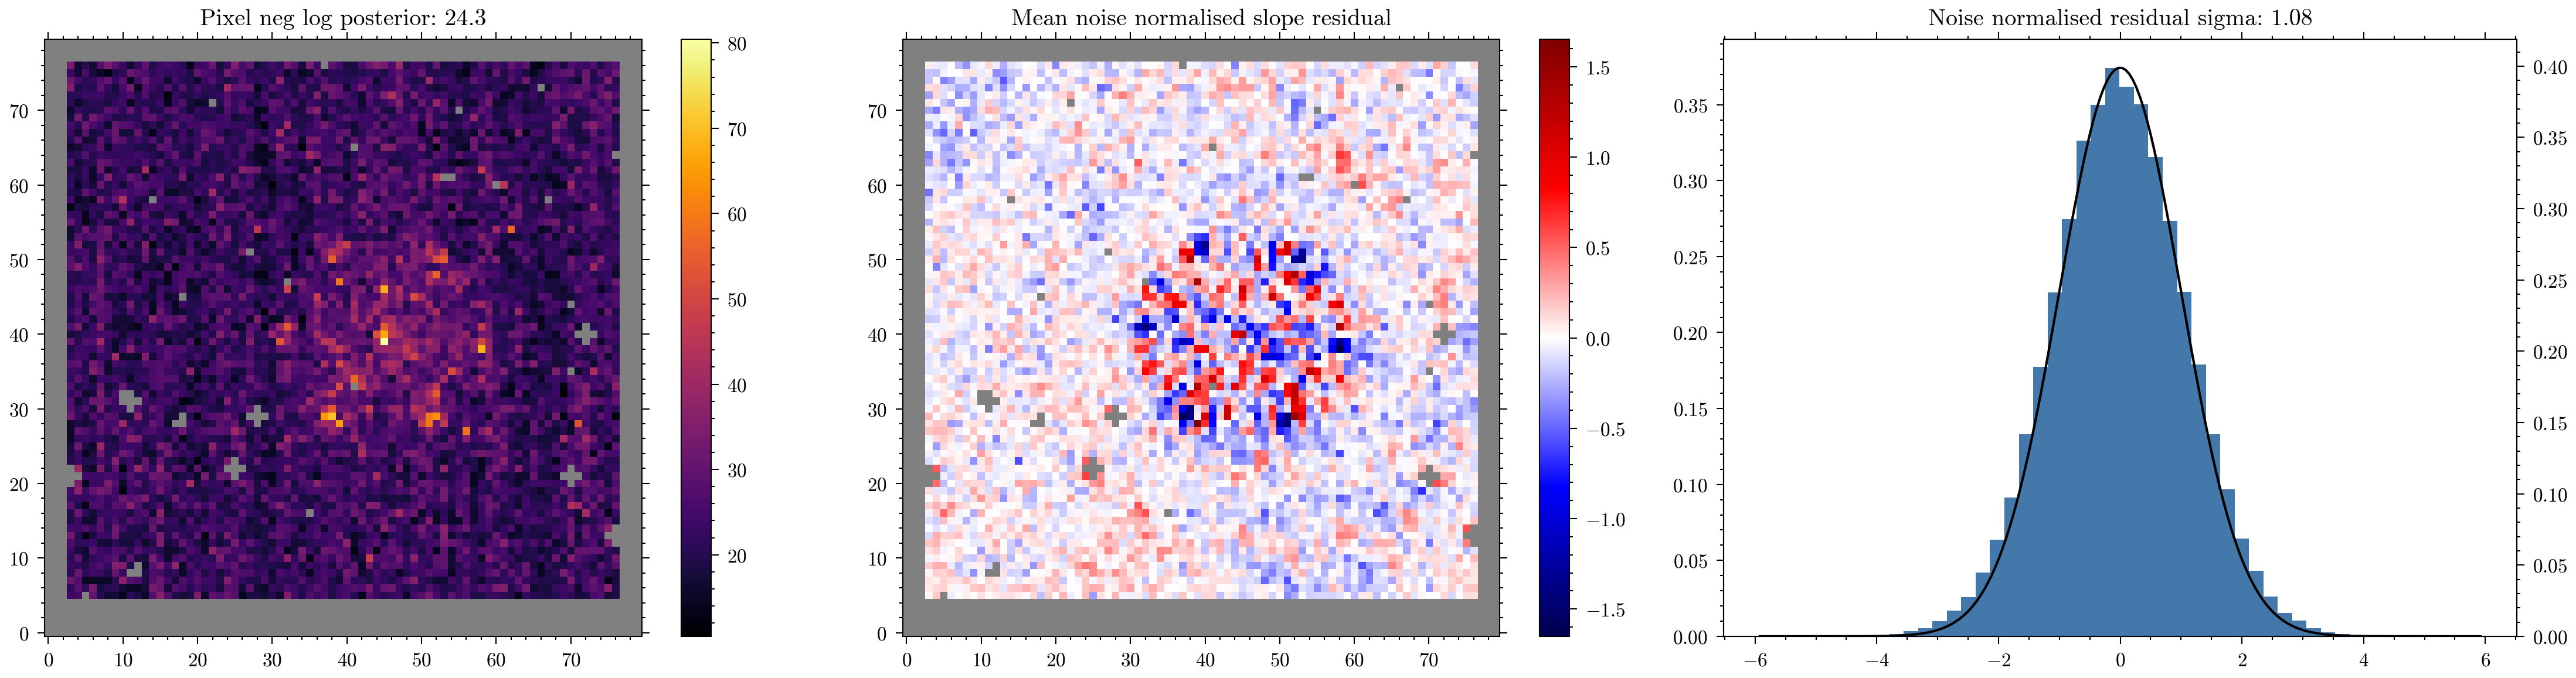

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in exps:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            amigo.plotting.summarise_fit(final_model, exp)

In [ ]:
# np.save("files/PDS70_CALFIT.npy", final_model.params, allow_pickle=True)